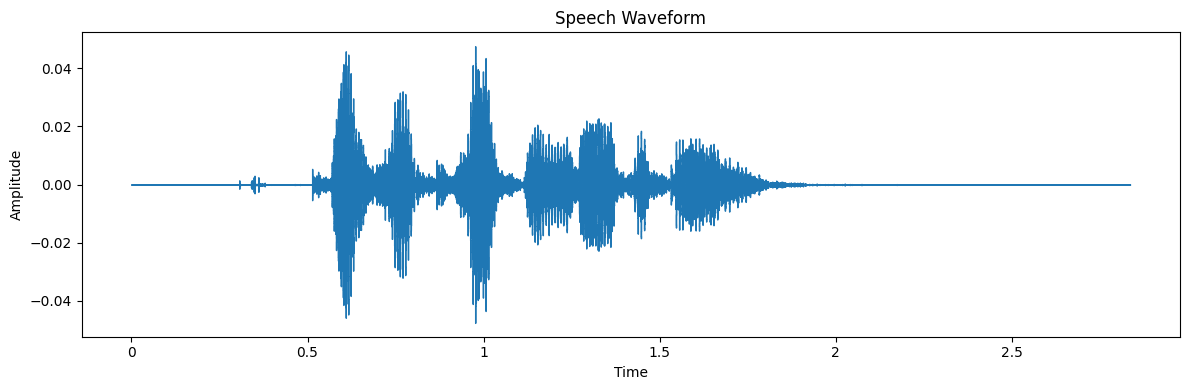

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

audio_path = "data/RAVDESS/Actor_01/03-01-01-01-01-02-01.wav"

audio, sr = librosa.load(audio_path, duration=3, offset=0.5)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title("Speech Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


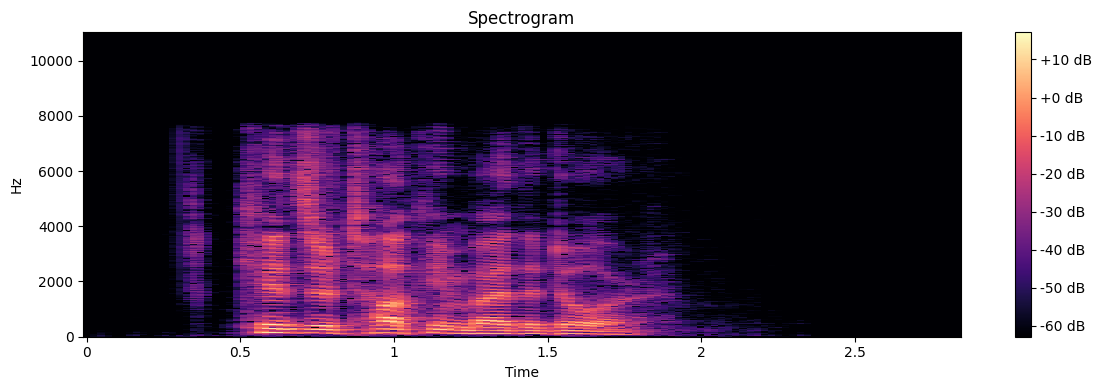

In [11]:
import numpy as np

# Convert audio to frequency domain using STFT
stft = librosa.stft(audio)

# Convert amplitude to decibel scale
spectrogram = librosa.amplitude_to_db(np.abs(stft))

# Plot spectrogram
plt.figure(figsize=(12, 4))
librosa.display.specshow(
    spectrogram,
    sr=sr,
    x_axis='time',
    y_axis='hz'
)
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.tight_layout()
plt.show()


In [12]:
# Extract MFCC features
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

print("MFCC shape:", mfcc.shape)


MFCC shape: (40, 123)


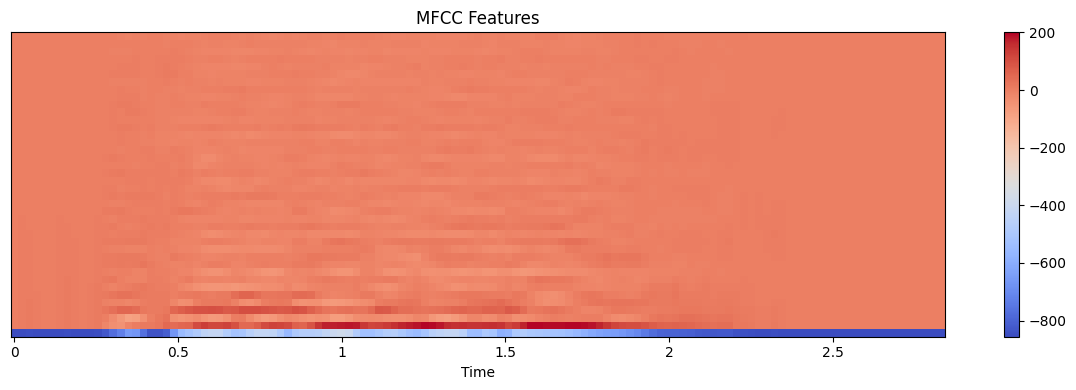

In [13]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(
    mfcc,
    sr=sr,
    x_axis='time'
)
plt.colorbar()
plt.title("MFCC Features")
plt.tight_layout()
plt.show()


In [14]:
import numpy as np

# Convert MFCC (40, time) -> (40,)
mfcc_mean = np.mean(mfcc.T, axis=0)

print("Final feature vector shape:", mfcc_mean.shape)
print(mfcc_mean)


Final feature vector shape: (40,)
[-6.6930560e+02  7.6373062e+01 -1.5135005e+01  2.9210396e+01
 -5.1104563e-01  7.0515938e+00 -8.5617037e+00 -2.7249599e+00
 -1.6439108e+01 -1.5938971e+00  1.1780567e+00 -5.5307598e+00
  3.2231967e+00 -7.3390546e+00  2.4943082e+00 -2.9060550e+00
 -2.9608209e+00 -3.6767821e+00 -8.4057218e-01 -7.1388876e-01
 -6.0503745e+00 -1.2312709e+00 -2.7010670e+00 -5.2596436e+00
 -1.4333707e+00 -1.7546057e+00 -5.9371591e+00  1.1010261e+00
 -2.5549200e+00 -6.4451128e-01 -9.2920923e-01 -4.1573811e+00
 -1.4084662e+00 -4.1479692e+00 -2.4008904e+00 -2.1814260e+00
 -4.8751581e-01 -4.4139910e+00 -3.0610540e+00 -3.1942546e+00]


In [15]:
# RAVDESS emotion mapping
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Extract emotion from filename
file_name = "03-01-01-01-01-02-01.wav"
emotion_code = file_name.split("-")[2]
emotion_label = emotion_map[emotion_code]

print("Emotion code:", emotion_code)
print("Emotion label:", emotion_label)


Emotion code: 01
Emotion label: neutral


In [16]:
import os
import numpy as np
import librosa

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

X = []
y = []

ravdess_path = "data/RAVDESS"

for actor_folder in os.listdir(ravdess_path):
    actor_path = os.path.join(ravdess_path, actor_folder)

    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            file_path = os.path.join(actor_path, file)

            audio, sr = librosa.load(file_path, duration=3, offset=0.5)

            # MFCC
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
            mfcc_mean = np.mean(mfcc.T, axis=0)

            # Delta MFCC
            delta_mfcc = librosa.feature.delta(mfcc)
            delta_mean = np.mean(delta_mfcc.T, axis=0)

            # Delta-Delta MFCC
            delta2_mfcc = librosa.feature.delta(mfcc, order=2)
            delta2_mean = np.mean(delta2_mfcc.T, axis=0)

            # Combine features
            combined_features = np.hstack([
                mfcc_mean,
                delta_mean,
                delta2_mean
            ])

            emotion_code = file.split("-")[2]
            emotion_label = emotion_map[emotion_code]

            X.append(combined_features)
            y.append(emotion_label)

print("Total samples:", len(X))
print("Feature vector size:", X[0].shape)


Total samples: 1439
Feature vector size: (120,)


In [17]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# Encode labels (text -> numbers)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded labels:", np.unique(y_encoded))
print("Emotion classes:", label_encoder.classes_)


X shape: (1439, 120)
y shape: (1439,)
Encoded labels: [0 1 2 3 4 5 6 7]
Emotion classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [18]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Before reshape:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Before reshape:
X_train shape: (1151, 120)
X_test shape: (288, 120)


In [19]:
# Reshape for CNN: (samples, features, channels)
X_train = X_train.reshape(X_train.shape[0], 40, 1)
X_test  = X_test.reshape(X_test.shape[0], 40, 1)

print("After reshape:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


ValueError: cannot reshape array of size 138120 into shape (1151,40,1)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, Flatten

# Build CNN model
model = Sequential()

# 1st Convolution layer
model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu',
    input_shape=(40, 1)
))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# 2nd Convolution layer
model.add(Conv1D(
    filters=128,
    kernel_size=3,
    activation='relu'
))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# Flatten before Dense layers
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

# Output layer (8 emotions)
model.add(Dense(8, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show model summary
model.summary()


C:\Users\KIIT0001\speech_emotion_analyzer\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 38, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 19, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 19, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 17, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 8, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 157,192 (614.03 KB)

 Trainable params: 157,192 (614.03 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the CNN model
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32
)


Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.1129 - loss: 5.8719 - val_accuracy: 0.1840 - val_loss: 2.0515
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1738 - loss: 2.1735 - val_accuracy: 0.1458 - val_loss: 2.0769
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1651 - loss: 2.1136 - val_accuracy: 0.1111 - val_loss: 2.0676
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.1651 - loss: 2.0708 - val_accuracy: 0.1701 - val_loss: 2.0233
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.1659 - loss: 2.0672 - val_accuracy: 0.1910 - val_loss: 2.0352
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.1677 - loss: 2.0724 - val_accuracy: 0.2153 - val_loss: 2.0000
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2120 - loss: 2.0257 - val_accuracy: 0.2569 - val_loss: 1.9287
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2207 - loss: 1.9949 - val_accuracy: 0.2882 - v

In [14]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4201 - loss: 1.6420
Test Loss: 1.6419563293457031
Test Accuracy: 0.4201388955116272


In [15]:
#increase accuracy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3719 - loss: 1.6622 - val_accuracy: 0.4062 - val_loss: 1.5943 - learning_rate: 0.0010
Epoch 2/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3658 - loss: 1.6250 - val_accuracy: 0.4340 - val_loss: 1.5633 - learning_rate: 0.0010
Epoch 3/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3962 - loss: 1.5979 - val_accuracy: 0.4062 - val_loss: 1.5648 - learning_rate: 0.0010
Epoch 4/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4179 - loss: 1.5733 - val_accuracy: 0.4306 - val_loss: 1.5652 - learning_rate: 0.0010
Epoch 5/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3831 - loss: 1.6129 - val_accuracy: 0.4236 - val_loss: 1.5915 - learning_rate: 0.0010
Epoch 6/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4075 - loss: 1.5588 - val_accuracy: 0.4306 - val_loss: 1.5557 - learning_rate: 0.0010
Epoch 7/80
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4075 - loss: 1.5849 - val_acc

In [16]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5486 - loss: 1.2084
Test Loss: 1.208421230316162
Test Accuracy: 0.5486111044883728


In [18]:
model.save("speech_emotion_model.h5")
print("Model saved successfully")


Model saved successfully


In [7]:
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("speech_emotion_model.h5")

print("Model loaded successfully")


Model loaded successfully


In [9]:
from sklearn.model_selection import train_test_split
import numpy as np

# Recreate train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


NameError: name 'X' is not defined